# Transferring of endothelial cell states from the Gut Cell Atlas (Elementaite, 2021) to Remapped Data Using the `scVI - scANVI` Pipeline

**Developed by:** Anna Maguza\
**Affiliation:** Faculty of Medicine, Würzburg University\
**Creation date:** 27th February 2025\
**Last modified date:** 27th February 2025

#### **Objective**

This notebook outlines the process for transferring endothelial cell states annotations from the Gut Cell Atlas (Elementaite, 2021) to a series of remapped datasets using the `scVI - scANVI` pipeline. Our goal is to ensure consistent annotation of cell types across studies and to identify cells requiring manual validation.\
We analyze the confidence scores produced by `scANVI` to identify cells with low classification certainty. These cells are flagged for potential manual review and validation to ensure the accuracy of the annotations.\
Finally, we evaluate the performance of the `scVI` and `scANVI` models using `scIB` metrics. This step helps quantify the quality of the integration, classification, and batch correction.

## Import packages

In [1]:
import scvi
import torch
import anndata
import warnings
import numpy as np
import scanpy as sc
import anndata
import pandas as pd
import plotnine as p
import matplotlib.pyplot as plt
import seaborn as sns
from scib_metrics.benchmark import Benchmarker

import json
from datetime import datetime

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup working environment

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi = 180, color_map = 'magma_r', dpi_save = 300, vector_friendly = True, format = 'svg')

In [3]:
warnings.simplefilter(action = 'ignore')
scvi.settings.seed = 1712
%config InlineBackend.print_figure_kwargs = {'facecolor' : "w"}
%config InlineBackend.figure_format = 'retina'
torch.set_float32_matmul_precision('medium')

Seed set to 1712


In [4]:
arches_params = dict(
    use_layer_norm = "both",
    use_batch_norm = "none",
    encode_covariates = True,
    dropout_rate = 0.2,
    n_layers = 3,
)

In [5]:
def X_is_raw(adata):
    return np.array_equal(adata.X.sum(axis=0).astype(int), adata.X.sum(axis=0))

In [6]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

## Upload data

In [7]:
adata = sc.read_h5ad('data/gut_data/gut_hs_all_datasets_scVI_scANVI_celltypes_AM_10012025_100142_raw.h5ad')
adata

AnnData object with n_obs × n_vars = 402343 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoc

In [8]:
adata.obs['celltype'] = adata.obs['C_scANVI']

In [9]:
adata = adata[adata.obs['celltype'].isin(['Endothelial'])].copy()

In [10]:
del adata.obs['_scvi_batch'], adata.obs['_scvi_labels'], adata.obs['C_scANVI'], adata.obs['confidence_score']
del adata.obsm
del adata.uns

In [11]:
adata

AnnData object with n_obs × n_vars = 12854 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoco

In [12]:
X_is_raw(adata)

True

## Prepare observations

+ Delete samples with less than 10 cells

In [19]:
cell_counts = adata.obs['sample_id'].value_counts()
samples_to_remove = cell_counts[cell_counts < 10].index
adata = adata[~adata.obs['sample_id'].isin(samples_to_remove)].copy()

+ Delete not mesenchymal cell states 

In [20]:
adata.obs['Integrated_05'].value_counts()

Integrated_05
Unknown               9348
venous capillary       892
Fetal arterial EC      460
Mature venous EC       438
Mature arterial EC     304
cycling EC             278
Fetal venous EC        267
LEC4 (STAB2+)          203
LEC6 (ADAMTS4+)        179
arterial capillary     128
LEC3 (ADGRG3+)          72
LEC1 (ACKR4+)           50
LEC5 (CLDN11+)          44
LEC2 (MADCAM1+)         19
Mesoderm 2 (ZEB2+)       1
Pericyte                 1
SMC (PLPP2+)             1
Name: count, dtype: int64

In [21]:
adata = adata[adata.obs['Integrated_05'] != 'Mesoderm 2 (ZEB2+)']
adata = adata[adata.obs['Integrated_05'] != 'Pericyte']
adata = adata[adata.obs['Integrated_05'] != 'SMC (PLPP2+)']

+ Relabel into broader annotation

In [22]:
cell_state_mapping = {
    'Unknown': 'Unknown',
    # Capillary
    'venous capillary': 'venous capillary',
    'arterial capillary': 'arterial capillary',
    # Arterial
    'Fetal arterial EC': 'Arterial EC',
    'Mature arterial EC': 'Arterial EC',
    # Venous
    'Mature venous EC': 'Venous EC',
    'Fetal venous EC': 'Venous EC',
    # LEC
    'LEC4 (STAB2+)': 'LEC',
    'LEC6 (ADAMTS4+)': 'LEC',
    'LEC3 (ADGRG3+)': 'LEC',
    'LEC1 (ACKR4+)': 'LEC',
    'LEC5 (CLDN11+)': 'LEC',
    'LEC2 (MADCAM1+)': 'LEC',
    # Cycling
    'cycling EC': 'cycling EC'
}


In [23]:
adata.obs['cell_state'] = adata.obs['Integrated_05'].map(cell_state_mapping)

In [24]:
adata.obs['cell_state'].value_counts()

cell_state
Unknown               9348
venous capillary       892
Arterial EC            764
Venous EC              705
LEC                    567
cycling EC             278
arterial capillary     128
Name: count, dtype: int64

## Visualize uncorrected dataset

In [33]:
adata_log = adata.copy()
sc.pp.normalize_total(adata_log, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(adata_log)

normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['S100A6', 'TMSB10', 'CCL20', 'ENSG00000286848', 'MMRN1', 'ATG10', 'ENSG00000271581', 'LINC01013', 'CD36', 'RPL30-AS1', 'CCL21', 'VIM-AS1', 'ADIRF-AS1', 'TALAM1', 'BTG1-DT', 'ENSG00000273149', 'ZFP36', 'FTL', 'TFF1', 'LGALS1', 'TMSB4X', 'MT-RNR1', 'MT-RNR2', 'MT-CO1', 'MT-CO3', 'MT-ND6']
    finished (0:00:00)


In [34]:
sc.pp.pca(adata_log)

computing PCA
    with n_comps=50
    finished (0:00:22)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [35]:
sc.pp.neighbors(adata_log, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata_log)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:10)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)


In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.pca(adata_log,color=['celltype', "Study_name", "ArrayExpress_ID", 'age_group', 'organism_part', 'developmental_stage', 'library_preparation_protocol', 'library_construnction_and_layout', 'Protocol REF', 'Performer'], ncols=4, frameon=False, show=False, size = 5)
    plt.savefig(f"figures/endothelial_pca_uncorrected_categorical_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.pca(adata_log,color=['immunophenotype', 'sex', 'Cell_cycle_phase', 'full_age', 'growth_condition', 'sampling_site', 'Material Type', 'donor_id', 'library_construnction_and_layout', 'Protocol REF', 'Performer'], ncols=4, frameon=False, show=False, size = 5)
    plt.savefig(f"figures/endothelial_pca_uncorrected_categorical_values2_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.pca(adata_log,color=['n_genes', 'n_counts', 'total_counts', 'n_genes_by_counts', 'predicted_doublets', 'percent_mito', 'percent_ribo', 'percent_hb'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 5)
    plt.savefig(f"figures/endothelial_pca_uncorrected_continues_values_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata_log,color=['celltype',"Study_name", "ArrayExpress_ID", 'age_group', 'organism_part', 'developmental_stage', 'library_preparation_protocol', 'library_construnction_and_layout', 'Protocol REF', 'Performer'], ncols=4, frameon=False, show=False, size = 5)
    plt.savefig(f"figures/endothelial_umap_uncorrected_categorical_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [41]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata_log,color=['immunophenotype', 'sex', 'Cell_cycle_phase', 'full_age', 'growth_condition', 'sampling_site', 'Material Type', 'donor_id', 'library_construnction_and_layout', 'Protocol REF', 'Performer'], ncols=4, frameon=False, show=False, size = 5)
    plt.savefig(f"figures/endothelial_umap_uncorrected_categorical_values2_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [42]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_log,color=['n_genes', 'n_counts', 'total_counts', 'n_genes_by_counts', 'predicted_doublets', 'percent_mito', 'percent_ribo', 'percent_hb'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 5)
    plt.savefig(f"figures/endothelial_umap_uncorrected_continues_values_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [36]:
adata.obsm['X_pca'] = adata_log.obsm['X_pca'].copy()
adata.obsm['umap_uncorrected'] = adata_log.obsm['X_umap'].copy()

In [37]:
del adata_log

In [38]:
adata_raw = adata.copy()

## Extract highly variable genes

We extract the highly variable genes from the old reference dataset.

In [86]:
adata_ref = sc.read_h5ad('data/gut_data/Integrated_4_datasets_05042024.h5ad')

In [87]:
adata_ref.layers["counts"] = adata_ref.X.copy()

In [90]:
sc.pp.highly_variable_genes(
    adata_ref,
    flavor = "seurat_v3",
    n_top_genes = 1500,
    layer = "counts",
    batch_key = "Library_Preparation_Protocol",
    subset = True,
    span = 1
)

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


In [91]:
genes_to_keep = adata_ref.var_names.intersection(adata.var_names)
adata = adata[:, genes_to_keep].copy()

In [92]:
del adata_ref

## Run scVI

In [93]:
adata.obs.rename(columns={'cell_state': 'cell_states'}, inplace=True)

In [94]:
adata.layers["counts"] = adata.X.copy()

In [95]:
scvi.model.SCVI.setup_anndata(adata, 
                              categorical_covariate_keys=['sample_id', 'library_construnction_and_layout', 'Performer', 'Protocol REF'],
                              labels_key = "cell_states", 
                              layer = 'counts')

In [97]:
scvi_model = scvi.model.SCVI(adata,
                            n_latent = 50, 
                            n_hidden = 128,
                            n_layers = 2, 
                            dropout_rate = 0.1,
                            dispersion = 'gene-batch', 
                            gene_likelihood = 'nb')

In [98]:
scvi_model.train(100, 
                early_stopping = True,
                early_stopping_patience = 10,
                check_val_every_n_epoch = 1, 
                enable_progress_bar = True)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 100/100: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:29<00:00,  1.15it/s, v_num=1, train_loss_step=400, train_loss_epoch=349]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:29<00:00,  1.12it/s, v_num=1, train_loss_step=400, train_loss_epoch=349]


In [99]:
adata.obsm["X_scVI"] = scvi_model.get_latent_representation(adata)

#### Evaluate model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

In [100]:
history_df = (
    scvi_model.history['elbo_train'].astype(float)
    .join(scvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars=['epoch'])
)

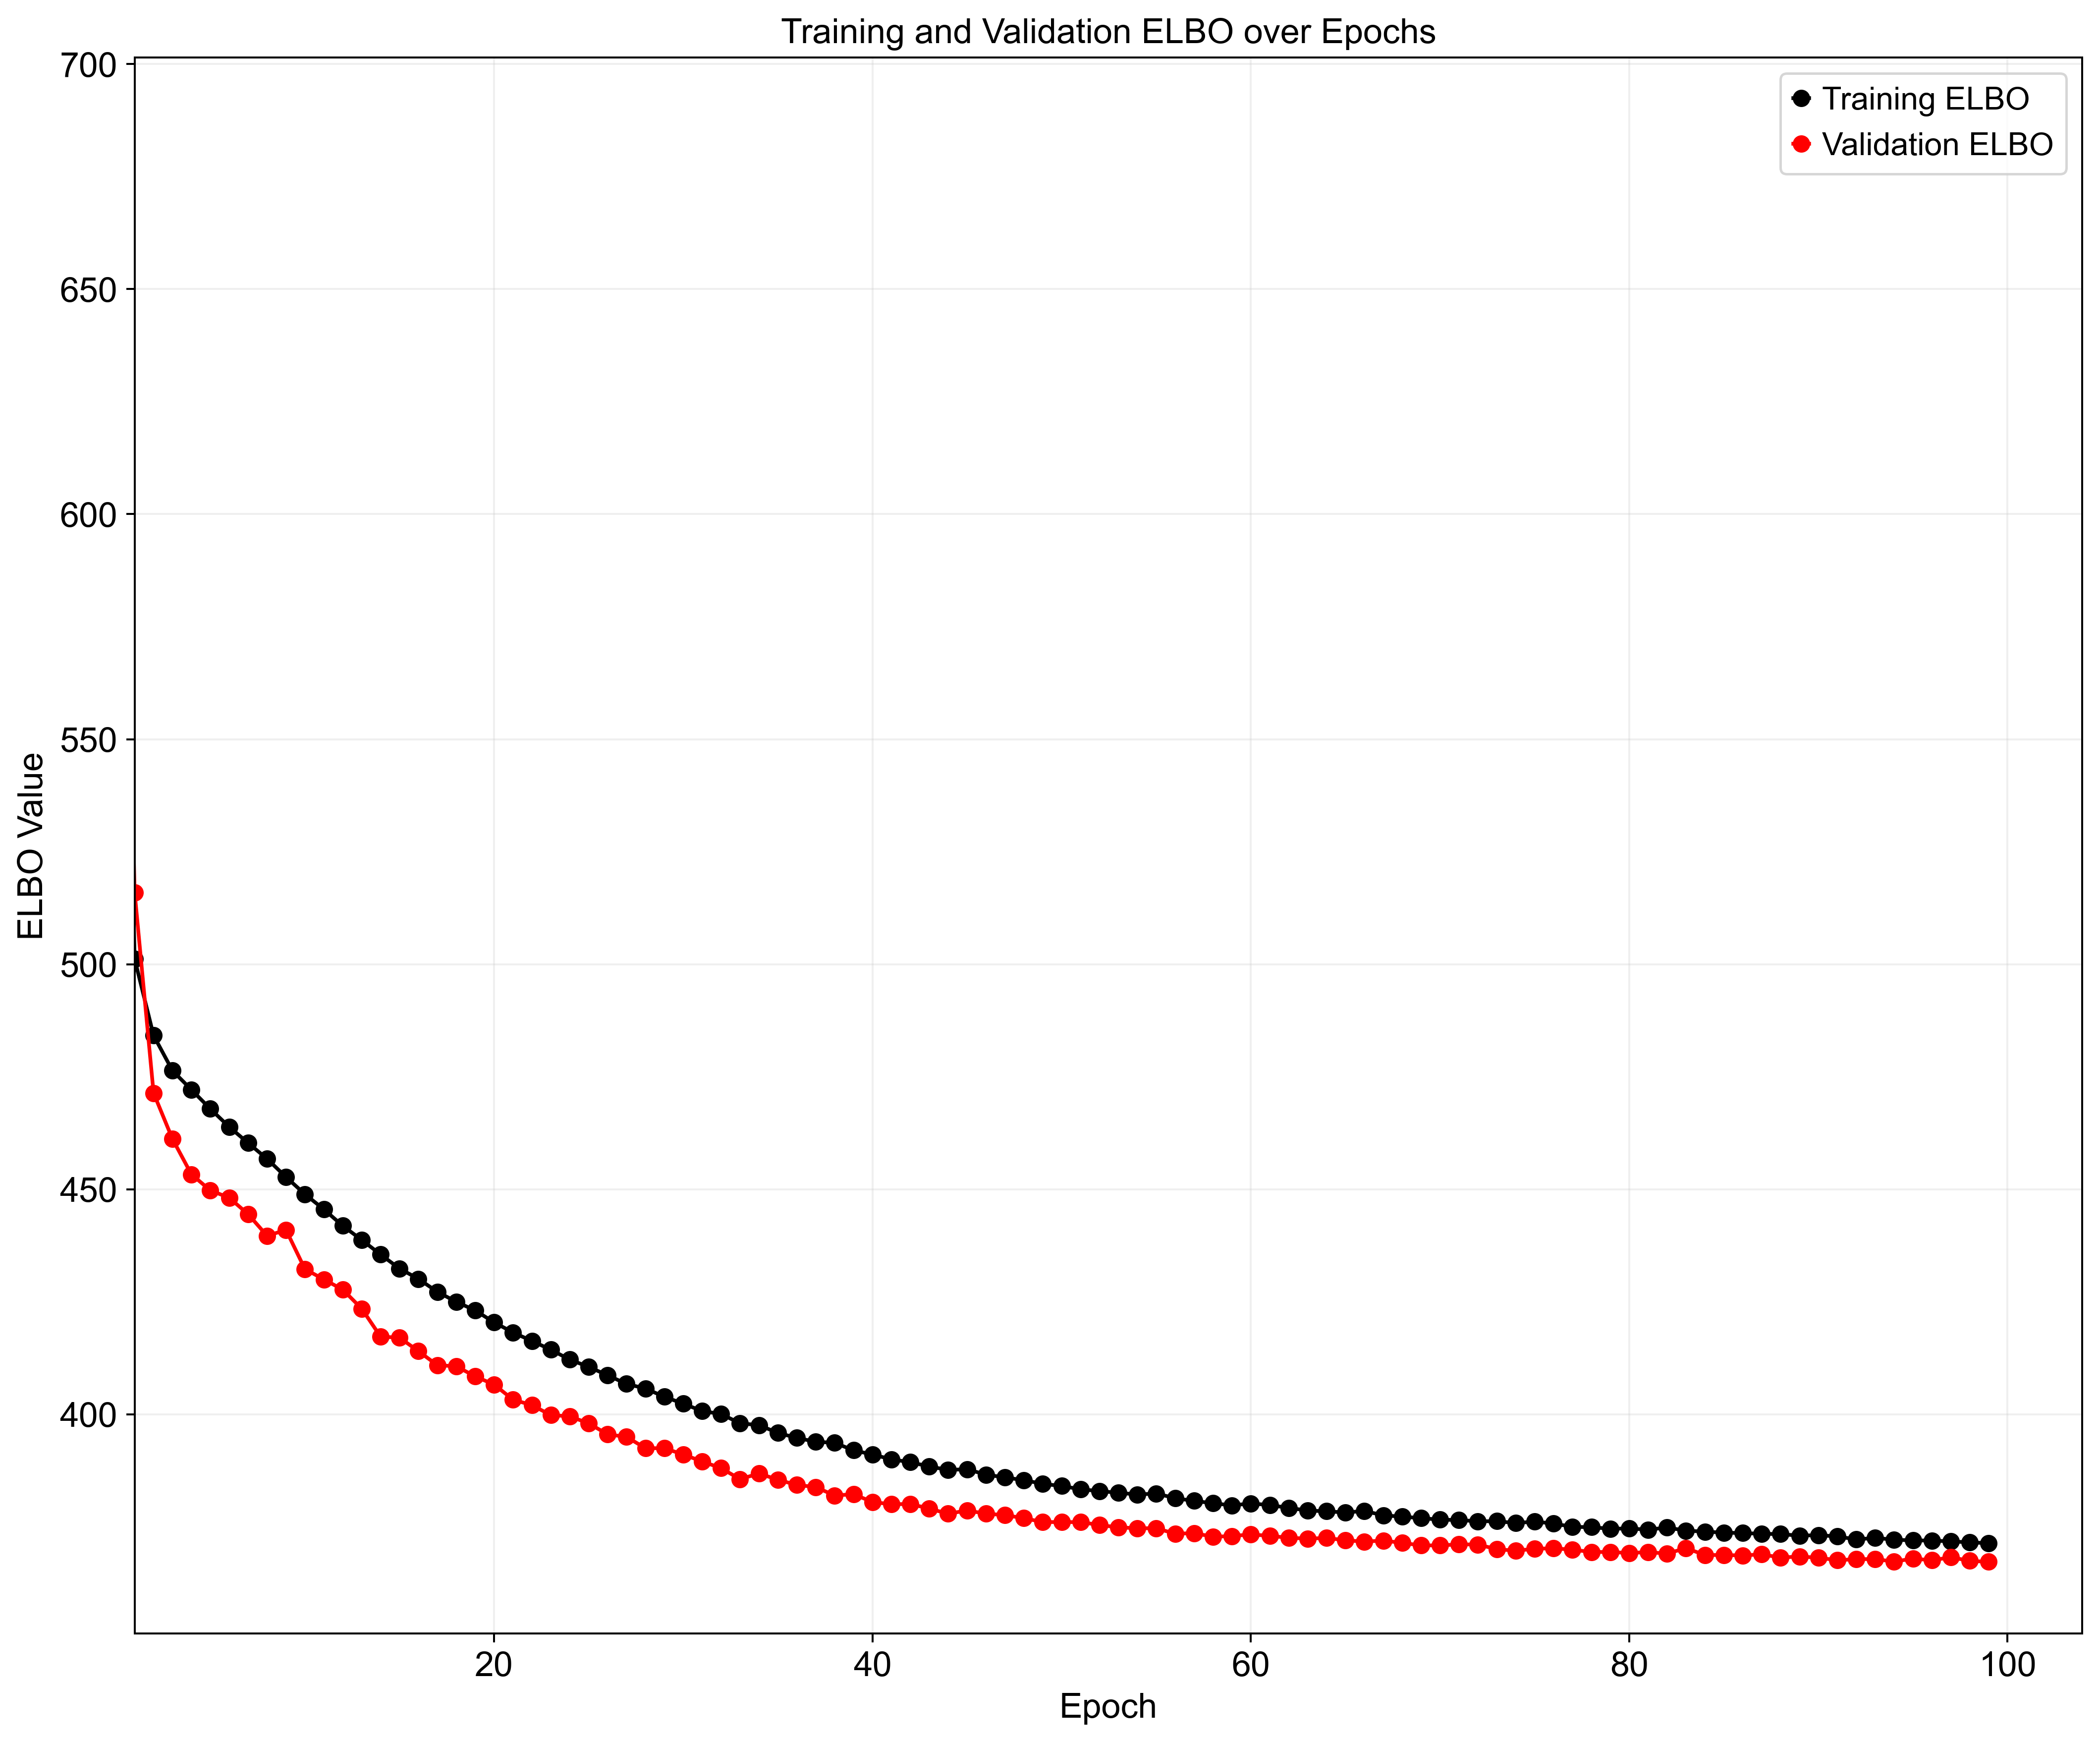

In [101]:
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

#### Label transfer with `scANVI` 

In [102]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(scvi_model, 'Unknown')

In [103]:
scanvi_model.train(150, 
                     early_stopping = True,
                   check_val_every_n_epoch = 1, 
                   enable_progress_bar = True)

INFO     Training for 150 epochs.                                                                                  


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 46/150:  31%|███████████████████████████████▉                                                                        | 46/150 [01:22<03:06,  1.79s/it, v_num=1, train_loss_step=420, train_loss_epoch=342]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 372.519. Signaling Trainer to stop.


In [104]:
adata.obs["cellstates_scANVI"] = scanvi_model.predict(adata)

- Extract latent representation

In [105]:
adata.obsm["X_scANVI"] = scanvi_model.get_latent_representation(adata)

### Explore model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

In [106]:
history_df = (
    scanvi_model.history['elbo_train'].astype(float)
    .join(scanvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars = ['epoch'])
)

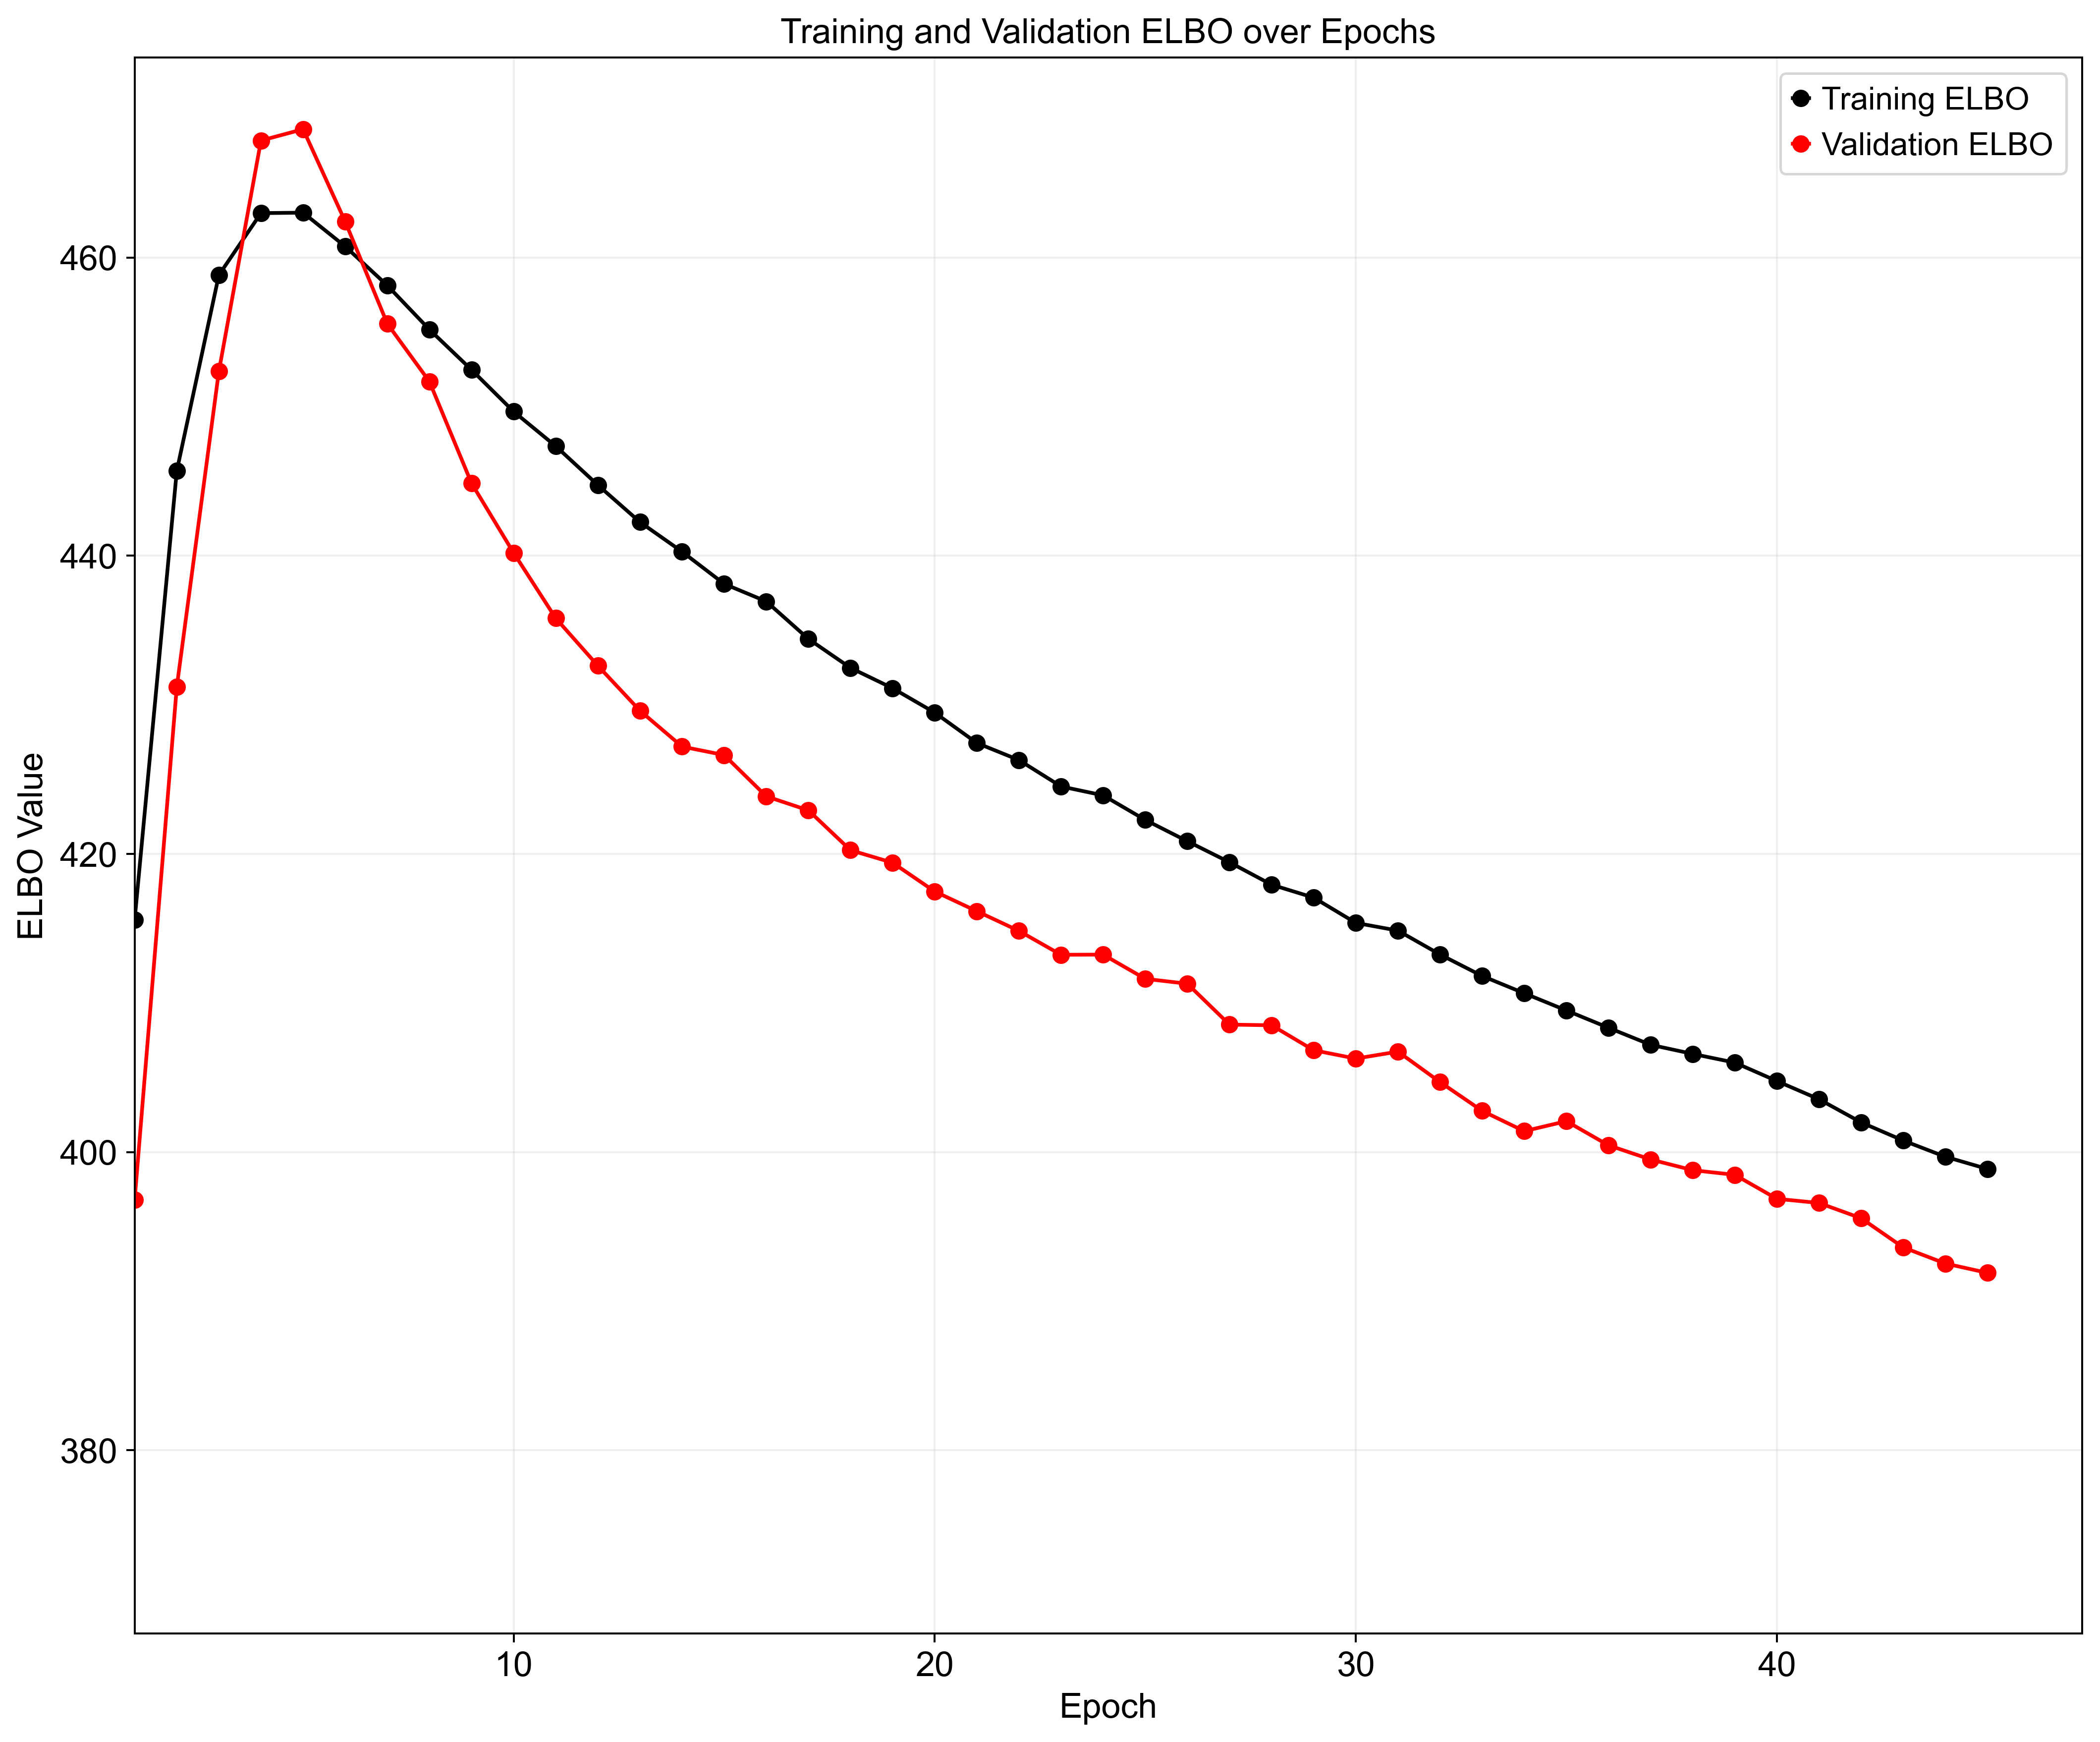

In [107]:
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

In [108]:
posterior_probs = scanvi_model.predict(adata, soft=True)

In [109]:
confidence_scores = posterior_probs.max(axis=1)

In [110]:
adata.obs['confidence_score'] = confidence_scores

+ Visualize dataset

In [115]:
sc.pp.neighbors(adata, use_rep = "X_scANVI", n_neighbors = 100, metric = 'minkowski')
sc.tl.umap(adata, min_dist = 0.6, spread = 8, random_state = 1712)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:06)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:08)


In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata,color=["cellstates_scANVI", "confidence_score", 'cell_states', 'Integrated_05'], ncols=1, frameon=False, show=False, size = 6)
    plt.savefig(f"figures/endothelial_cellstates_transfer_categorical_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata,color=["Study_name", "ArrayExpress_ID", 'age_group', 'organism_part', 
                            'developmental_stage', 'library_preparation_protocol', 'immunophenotype', 'developmental_stage'], ncols=4, frameon=False, show=False, size = 6)
    plt.savefig(f"figures/endothelial_cellstates_transfer_categorical_values2_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['sex', 'Cell_cycle_phase', 'sampling_site', 'full_age', 
                            'library_construnction_and_layout', 'Protocol REF', 'Performer', 'growth_condition', 
                            'Material Type', 'donor_id'], ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"figures/endothelial_cellstates_transfer_categorical_values3_{timestamp}.png", bbox_inches="tight")
    #plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['n_genes', 'n_counts', 'total_counts', 'n_genes_by_counts', 'predicted_doublets', 'percent_mito', 'percent_ribo', 'percent_hb'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"figures/endothelial_cellstates_transfer_continues_values_{timestamp}.png", bbox_inches="tight")
    #plt.show()

## Save prepared dataset

In [120]:
adata_export= adata_raw.copy()
adata_export

AnnData object with n_obs × n_vars = 12390 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoco

In [121]:
adata_export.obs['cellstates_scANVI'] = adata.obs['cellstates_scANVI'].copy()
adata_export.obs['confidence_score'] = adata.obs['confidence_score'].copy()
adata_export.obsm['X_scVI'] = adata.obsm['X_scVI'].copy()
adata_export.obsm['X_scANVI'] = adata.obsm['X_scANVI'].copy()
adata_export.obsm['X_pca'] = adata.obsm['X_pca'].copy()
adata_export.obsm['umap_uncorrected'] = adata.obsm['umap_uncorrected'].copy()
adata_export.obsm['X_umap'] = adata.obsm['X_umap'].copy()

In [122]:
#current_history = adata_export.uns['processing_history']

new_entry = json.dumps({
    'timestamp': timestamp,
    'step': 'Extracted genes (1500, library_preparation_protocol - batch. using old reference), merged small populations into one group, fixed bolean nan issue, deleted samples with less than 10 cells, deleted doublets, predicted endothelial cell states using scVI-scANVI, scvi params: batch = sample_id, library_construnction_and_layout,Performer and Protocol REF, n_latent = 50, n_hidden = 128, n_layers = 2, dropout_rate = 0.1, dispersion = gene-batch, gene_likelihood = nb, 100 epochs, scanvi params: 150 epochs',
})
#current_history.append(new_entry)

adata_export.uns['processing_history'] = new_entry

In [123]:
adata_export.obs.rename(columns={'cell_id': 'cell_index'}, inplace=True)

In [124]:
project = 'gut'
species = 'hs'
name = 'AM'
counts = 'raw'
atribute = 'all_datasets_scVI_scANVI_endothelial_cellstates'

adata_export.write_h5ad(f"data/gut_data/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")

In [125]:
adata.obs["cellstates_scANVI"].value_counts()

cellstates_scANVI
venous capillary      4686
Venous EC             2827
Arterial EC           2458
LEC                   1181
cycling EC            1076
arterial capillary     162
Name: count, dtype: int64